# *First we import our libaries *

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import zipfile

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Bring our dataset to project

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dragonheir/logistic-regression")

print("Path to dataset files:", path)

100%|██████████| 3.27k/3.27k [00:00<00:00, 2.19MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dragonheir/logistic-regression/versions/1


## Starting our EDA

In [3]:
csv_path = os.path.join(path, "Social_Network_Ads.csv")

df_ads = pd.read_csv(csv_path)
df_ads.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df_ads.head()


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df_ads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


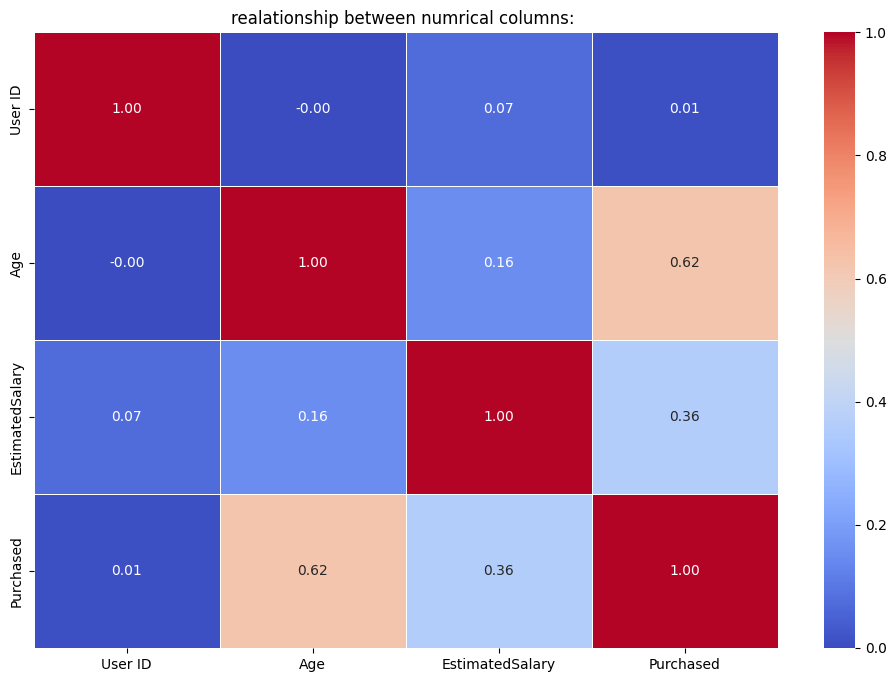

In [6]:
numeric_df = df_ads.select_dtypes(include=['int64', 'float64'])

# 2. حساب مصفوفة الارتباط
corr_matrix = numeric_df.corr()

# 3. رسم الخريطة الحرارية (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,       # لإظهار الأرقام داخل المربعات
            cmap='coolwarm',  # اختيار ألوان توضح الموجب والسالب
            fmt=".2f",        # تقريب الأرقام لفاصلتين عشريتين
            linewidths=0.5)

plt.title("realationship between numrical columns: ")
plt.show()

In [7]:
columns_to_check = ['Age', 'EstimatedSalary']

# دالة لاكتشاف القيم الشاذة رياضياً باستخدام طريقة (IQR)
def detect_outliers_iqr(data, column):
    # حساب الربيع الأول (25%) والربيع الثالث (75%)
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    # حساب المدى الربيعي
    IQR = Q3 - Q1

    # تحديد الحد الأدنى والأعلى المسموح به للبيانات الطبيعية
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # استخراج الصفوف التي تتجاوز هذه الحدود (القيم الشاذة)
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# تطبيق الدالة على الأعمدة وطباعة النتائج
for col in columns_to_check:
    outliers_df = detect_outliers_iqr(df_ads, col)

    print(f"--- نتيجة الفحص لعمود: {col} ---")
    if outliers_df.empty:
        print("✅ لا توجد قيم شاذة.")
    else:
        print(f"⚠️ تم العثور على {len(outliers_df)} قيمة شاذة:")
        print(outliers_df)
    print("-" * 40 + "\n")

--- نتيجة الفحص لعمود: Age ---
✅ لا توجد قيم شاذة.
----------------------------------------

--- نتيجة الفحص لعمود: EstimatedSalary ---
✅ لا توجد قيم شاذة.
----------------------------------------



In [8]:
missing_values = df_ads.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


# **Doing the encoding and Scaling on our data.**

In [9]:
X = df_ads.drop('Purchased', axis=1)
y = df_ads['Purchased']

# 2. تقسيم البيانات إلى تدريب (80%) واختبار (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# طباعة الأبعاد للتأكد من نجاح التقسيم
print("شكل بيانات التدريب X_train:", X_train.shape)
print("شكل بيانات الاختبار X_test:", X_test.shape)
print("شكل بيانات التدريب y_train:", y_train.shape)
print("شكل بيانات الاختبار y_test:", y_test.shape)

شكل بيانات التدريب X_train: (320, 4)
شكل بيانات الاختبار X_test: (80, 4)
شكل بيانات التدريب y_train: (320,)
شكل بيانات الاختبار y_test: (80,)


In [10]:
le = LabelEncoder()

# تطبيق التشفير على عمود Gender في بيانات التدريب (fit_transform)
X_train['Gender'] = le.fit_transform(X_train['Gender'])

# تطبيق التشفير على نفس العمود في بيانات الاختبار (transform فقط)
X_test['Gender'] = le.transform(X_test['Gender'])


X_train = X_train.drop('User ID', axis=1)
X_test = X_test.drop('User ID', axis=1)

In [11]:
scaler = StandardScaler()
cols_to_scale = ['Age', 'EstimatedSalary']


X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])


X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [12]:
# التحقق من أبعاد البيانات (عدد الصفوف والأعمدة)
print("أبعاد X_train:", X_train.shape)
print("أبعاد X_test:", X_test.shape)
print("-" * 50)


print("أول 5 صفوف من بيانات التدريب:")
display(X_train.head())
print("-" * 50)


print("الملخص الإحصائي لبيانات التدريب بعد التقييس:")
display(X_train.describe().round(3))

أبعاد X_train: (320, 3)
أبعاد X_test: (80, 3)
--------------------------------------------------
أول 5 صفوف من بيانات التدريب:


,Gender,Age,EstimatedSalary
3,0,-1.066752,-0.386344
18,1,0.797535,-1.229939
202,0,0.110692,1.853544
250,0,0.601294,-0.909955
274,0,1.876859,-1.288118


--------------------------------------------------
الملخص الإحصائي لبيانات التدريب بعد التقييس:


,Gender,Age,EstimatedSalary
count,320.000,320.000,320.000
mean,0.500,-0.000,0.000
std,0.501,1.002,1.002
min,0.000,-1.950,-1.608
25%,0.000,-0.772,-0.794
50%,0.500,-0.086,0.021
75%,1.000,0.699,0.515
max,1.000,2.171,2.319


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import pandas as pd


log_reg = LogisticRegression(random_state=42)

# =====================================================================
# 2. التقييم المتقاطع (Cross-Validation) المطابق لـ Stratified K-Fold
# =====================================================================
print("--- نتائج التقييم المتقاطع (Cross Validation) ---")
# cv=5 تعني أنه سيقسم البيانات إلى 5 أقسام لتدريب واختبار النموذج
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='accuracy')

print(f"دقة كل قسم من الأقسام الخمسة: {cv_scores}")
print(f"متوسط الدقة (Mean Accuracy): {cv_scores.mean():.4f}")
print(f"الانحراف المعياري (Standard Deviation): {cv_scores.std():.4f}")
print("="*50 + "\n")

--- نتائج التقييم المتقاطع (Cross Validation) ---
دقة كل قسم من الأقسام الخمسة: [0.796875 0.859375 0.828125 0.78125  0.8125  ]
متوسط الدقة (Mean Accuracy): 0.8156
الانحراف المعياري (Standard Deviation): 0.0269



In [14]:
# =====================================================================
# 3. تدريب النموذج النهائي والتنبؤ
# =====================================================================
# التدريب على كامل بيانات X_train و y_train
log_reg.fit(X_train, y_train)

# التنبؤ باستخدام بيانات الاختبار X_test
y_pred = log_reg.predict(X_test)

# =====================================================================
# 4. إحصائيات النموذج الرياضية (Model Parameters)
# =====================================================================
print("--- إحصائيات النموذج (الرياضية) ---")
print(f"نقطة التقاطع (Intercept): {log_reg.intercept_[0]:.4f}")
print("الأوزان/المعاملات (Coefficients) لكل عمود:")
# طباعة وزن كل ميزة (Feature) لمعرفة مدى تأثيرها في القرار
for col, coef in zip(X_train.columns, log_reg.coef_[0]):
    print(f"  - {col}: {coef:.4f}")
print("="*50 + "\n")

# =====================================================================
# 5. إحصائيات التقييم (Metrics)
# =====================================================================
print("--- إحصائيات تقييم الأداء (Classification Metrics) ---")
print(f"1. الدقة الإجمالية (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"2. دقة التنبؤ الإيجابي (Precision): {precision_score(y_test, y_pred):.4f}")
print(f"3. حساسية النموذج/الاستدعاء (Recall): {recall_score(y_test, y_pred):.4f}")
print(f"4. المقياس المدمج (F1-Score): {f1_score(y_test, y_pred):.4f}")

--- إحصائيات النموذج (الرياضية) ---
نقطة التقاطع (Intercept): -1.1323
الأوزان/المعاملات (Coefficients) لكل عمود:
  - Gender: 0.2561
  - Age: 1.9879
  - EstimatedSalary: 1.1442

--- إحصائيات تقييم الأداء (Classification Metrics) ---
1. الدقة الإجمالية (Accuracy): 0.8875
2. دقة التنبؤ الإيجابي (Precision): 0.9130
3. حساسية النموذج/الاستدعاء (Recall): 0.7500
4. المقياس المدمج (F1-Score): 0.8235


In [21]:
print("\n---(Classification Report) ---")
print(classification_report(y_test, y_pred))


---(Classification Report) ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, classification_report
import numpy as np


log_reg = LogisticRegression(random_state=42)

# =====================================================================
# 2. التدريب المتقاطع مع الاحتفاظ بالنماذج (return_estimator=True)
# =====================================================================
# دالة cross_validate ستعيد لنا قاموساً (Dictionary) يحتوي على أوقات التدريب، الدرجات، والنماذج
cv_results = cross_validate(log_reg, X_train, y_train, cv=5, scoring='accuracy', return_estimator=True)

# استخراج قائمة درجات الدقة لكل Fold
scores = cv_results['test_score']
print("--- نتائج التدريب المتقاطع (Stratified K-Fold) ---")
print(f"درجات الدقة لكل قسم: {scores}")

# =====================================================================
# 3. العثور على أفضل نموذج واستخراجه
# =====================================================================
# دالة argmax من numpy تعطينا "موقع" أو "مؤشر" أعلى قيمة في المصفوفة
best_fold_index = np.argmax(scores)

print(f"\nأفضل قسم هو القسم رقم: {best_fold_index + 1} بدقة بلغت: {scores[best_fold_index]:.4f}")


best_model = cv_results['estimator'][best_fold_index]
print("تم استخراج أفضل نموذج بنجاح!\n")
print("="*50 + "\n")

# =====================================================================
# 4. التنبؤ والتقييم باستخدام النموذج الأفضل فقط
# =====================================================================

y_pred_best = best_model.predict(X_test)

print("--- أداء (النموذج الأفضل) على بيانات الاختبار X_test ---")
print(f"الدقة الإجمالية (Accuracy): {accuracy_score(y_test, y_pred_best):.4f}")

print("\nالتقرير الشامل (Classification Report):")
print(classification_report(y_test, y_pred_best))

--- نتائج التدريب المتقاطع (Stratified K-Fold) ---
درجات الدقة لكل قسم: [0.796875 0.859375 0.828125 0.78125  0.8125  ]

أفضل قسم هو القسم رقم: 2 بدقة بلغت: 0.8594
تم استخراج أفضل نموذج بنجاح!


--- أداء (النموذج الأفضل) على بيانات الاختبار X_test ---
الدقة الإجمالية (Accuracy): 0.9000

التقرير الشامل (Classification Report):
              precision    recall  f1-score   support

           0       0.89      0.96      0.93        52
           1       0.92      0.79      0.85        28

    accuracy                           0.90        80
   macro avg       0.90      0.87      0.89        80
weighted avg       0.90      0.90      0.90        80



In [23]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import pandas as pd
import numpy as np

# 1. تهيئة نموذج SVM بنواة خطية (Linear Kernel)
# تم تفعيل النواة الخطية لنتمكن من قراءة الأوزان الرياضية لكل ميزة

svm_model = SVC(kernel='rbf', random_state=42)

# =====================================================================
# 2. التدريب المتقاطع مع الاحتفاظ بالنماذج (Stratified K-Fold)
# =====================================================================
print("--- نتائج التدريب المتقاطع (Stratified K-Fold) لنموذج SVM ---")
cv_results = cross_validate(svm_model, X_train, y_train, cv=5, scoring='accuracy', return_estimator=True)

scores = cv_results['test_score']
print(f"درجات الدقة لكل قسم: {scores}")

# =====================================================================
# 3. العثور على أفضل نموذج واستخراجه
# =====================================================================
best_fold_index = np.argmax(scores)
print(f"\nأفضل قسم هو القسم رقم: {best_fold_index + 1} بدقة بلغت: {scores[best_fold_index]:.4f}")

best_svm_model = cv_results['estimator'][best_fold_index]
print("تم استخراج أفضل نموذج SVM بنجاح!\n")
print("="*50 + "\n")

--- نتائج التدريب المتقاطع (Stratified K-Fold) لنموذج SVM ---
درجات الدقة لكل قسم: [0.921875 0.96875  0.875    0.875    0.890625]

أفضل قسم هو القسم رقم: 2 بدقة بلغت: 0.9688
تم استخراج أفضل نموذج SVM بنجاح!




In [24]:
# =====================================================================
# 4. التنبؤ باستخدام أفضل نموذج
# =====================================================================
y_pred_best_svm = best_svm_model.predict(X_test)

# =====================================================================
# =====================================================================
# 5. إحصائيات النموذج (الرياضية) - معدلة لتناسب النواة غير الخطية
# =====================================================================
print("--- إحصائيات نموذج SVM ---")
print(f"نوع النواة المستخدمة: {best_svm_model.kernel}")
print(f"إجمالي عدد متجهات الدعم (Support Vectors) التي اعتمد عليها النموذج: {len(best_svm_model.support_)}")
# The weights (coef_) and intercept (intercept_) have been removed because they are incompatible with the RBF kernel.
print("="*50 + "\n")

# =====================================================================
# 6. إحصائيات التقييم (Metrics)
# =====================================================================
print("--- أداء (أفضل نموذج SVM) على بيانات الاختبار X_test ---")
print(f"1. الدقة الإجمالية (Accuracy): {accuracy_score(y_test, y_pred_best_svm):.4f}")
print(f"2. دقة التنبؤ الإيجابي (Precision): {precision_score(y_test, y_pred_best_svm):.4f}")
print(f"3. حساسية النموذج/الاستدعاء (Recall): {recall_score(y_test, y_pred_best_svm):.4f}")
print(f"4. المقياس المدمج (F1-Score): {f1_score(y_test, y_pred_best_svm):.4f}")

print("\n--- مصفوفة الارتباك (Confusion Matrix) ---")
cm_svm = confusion_matrix(y_test, y_pred_best_svm)
cm_svm_df = pd.DataFrame(cm_svm,
                         columns=['تنبؤ 0 (لم يشتري)', 'تنبؤ 1 (اشترى)'],
                         index=['الفعلي 0', 'الفعلي 1'])
print(cm_svm_df)

print("\n--- التقرير الشامل (Classification Report) ---")
print(classification_report(y_test, y_pred_best_svm))

--- إحصائيات نموذج SVM ---
نوع النواة المستخدمة: rbf
إجمالي عدد متجهات الدعم (Support Vectors) التي اعتمد عليها النموذج: 86

--- أداء (أفضل نموذج SVM) على بيانات الاختبار X_test ---
1. الدقة الإجمالية (Accuracy): 0.9250
2. دقة التنبؤ الإيجابي (Precision): 0.8667
3. حساسية النموذج/الاستدعاء (Recall): 0.9286
4. المقياس المدمج (F1-Score): 0.8966

--- مصفوفة الارتباك (Confusion Matrix) ---
          تنبؤ 0 (لم يشتري)  تنبؤ 1 (اشترى)
الفعلي 0                 48               4
الفعلي 1                  2              26

--- التقرير الشامل (Classification Report) ---
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import pandas as pd
import numpy as np

# 1. تهيئة نموذج KNN
# سنختار عدد الجيران المبدئي ليكون 5، وهو الرقم الافتراضي والأكثر شيوعاً كنقطة بداية
knn_model = KNeighborsClassifier(n_neighbors=5)

# =====================================================================
# 2. التدريب المتقاطع مع الاحتفاظ بالنماذج (Stratified K-Fold)
# =====================================================================
print("--- نتائج التدريب المتقاطع (Stratified K-Fold) لنموذج KNN ---")
cv_results = cross_validate(knn_model, X_train, y_train, cv=5, scoring='accuracy', return_estimator=True)

scores = cv_results['test_score']
print(f"درجات الدقة لكل قسم: {scores}")

# =====================================================================
# 3. العثور على أفضل نموذج واستخراجه
# =====================================================================
best_fold_index = np.argmax(scores)
print(f"\nأفضل قسم هو القسم رقم: {best_fold_index + 1} بدقة بلغت: {scores[best_fold_index]:.4f}")

best_knn_model = cv_results['estimator'][best_fold_index]
print("تم استخراج أفضل نموذج KNN بنجاح!\n")
print("="*50 + "\n")

# =====================================================================


--- نتائج التدريب المتقاطع (Stratified K-Fold) لنموذج KNN ---
درجات الدقة لكل قسم: [0.890625 0.96875  0.859375 0.875    0.890625]

أفضل قسم هو القسم رقم: 2 بدقة بلغت: 0.9688
تم استخراج أفضل نموذج KNN بنجاح!




In [26]:
# 4. التنبؤ باستخدام أفضل نموذج

y_pred_best_knn = best_knn_model.predict(X_test)


# 5. إحصائيات النموذج (الرياضية / الهيكلية)

print("--- إحصائيات الهيكل الداخلي لنموذج KNN الأفضل ---")
print(f"عدد الجيران (K) المعتمد في القرار: {best_knn_model.n_neighbors}")
print(f"نوع مقياس المسافة المستخدم: {best_knn_model.metric} (حيث minkowski مع p=2 يعادل المسافة الإقليدية Euclidean)")
print(f"إجمالي عدد نقاط التدريب التي يحفظها النموذج لحساب المسافات: {best_knn_model.n_samples_fit_}")
print("="*50 + "\n")

# =====================================================================
# 6. إحصائيات التقييم (Metrics)
# =====================================================================
print("--- أداء (أفضل نموذج KNN) على بيانات الاختبار X_test ---")
print(f"1. الدقة الإجمالية (Accuracy): {accuracy_score(y_test, y_pred_best_knn):.4f}")
print(f"2. دقة التنبؤ الإيجابي (Precision): {precision_score(y_test, y_pred_best_knn):.4f}")
print(f"3. حساسية النموذج/الاستدعاء (Recall): {recall_score(y_test, y_pred_best_knn):.4f}")
print(f"4. المقياس المدمج (F1-Score): {f1_score(y_test, y_pred_best_knn):.4f}")

print("\n--- مصفوفة الارتباك (Confusion Matrix) ---")
cm_knn = confusion_matrix(y_test, y_pred_best_knn)
cm_knn_df = pd.DataFrame(cm_knn,
                         columns=['تنبؤ 0 (لم يشتري)', 'تنبؤ 1 (اشترى)'],
                         index=['الفعلي 0', 'الفعلي 1'])
print(cm_knn_df)

print("\n--- التقرير الشامل (Classification Report) ---")
print(classification_report(y_test, y_pred_best_knn))

--- إحصائيات الهيكل الداخلي لنموذج KNN الأفضل ---
عدد الجيران (K) المعتمد في القرار: 5
نوع مقياس المسافة المستخدم: minkowski (حيث minkowski مع p=2 يعادل المسافة الإقليدية Euclidean)
إجمالي عدد نقاط التدريب التي يحفظها النموذج لحساب المسافات: 256

--- أداء (أفضل نموذج KNN) على بيانات الاختبار X_test ---
1. الدقة الإجمالية (Accuracy): 0.9375
2. دقة التنبؤ الإيجابي (Precision): 0.8966
3. حساسية النموذج/الاستدعاء (Recall): 0.9286
4. المقياس المدمج (F1-Score): 0.9123

--- مصفوفة الارتباك (Confusion Matrix) ---
          تنبؤ 0 (لم يشتري)  تنبؤ 1 (اشترى)
الفعلي 0                 49               3
الفعلي 1                  2              26

--- التقرير الشامل (Classification Report) ---
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        52
           1       0.90      0.93      0.91        28

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94    